## Session 23 - Breast Cancer dataset
#### Link of Dataset : https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

In [27]:
'''
Import Required Libraries
'''

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save Model
import joblib

In [28]:
'''
Load Dataset
'''

# Load dataset
df = pd.read_csv("Employee-Attrition.csv")

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

First 5 Rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_wor

In [29]:
'''
Data Cleaning & Preprocessing
'''

# Drop unnecessary columns
df.drop(["id", "Unnamed: 32"], axis=1, inplace=True)

# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Encode Target Variable
# M = 1 (Malignant)
# B = 0 (Benign)
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

# Separate Features and Target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst 5 Rows:")
print(X.head())

Duplicate Rows: 0

Shape of X: (569, 30)
Shape of y: (569,)

First 5 Rows:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimens

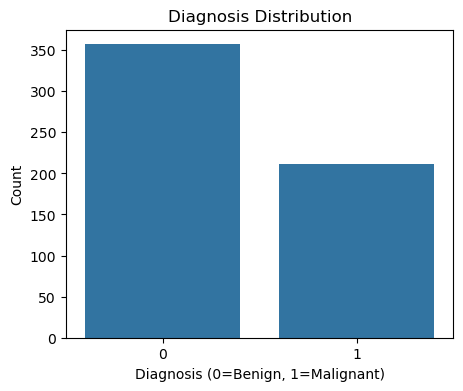

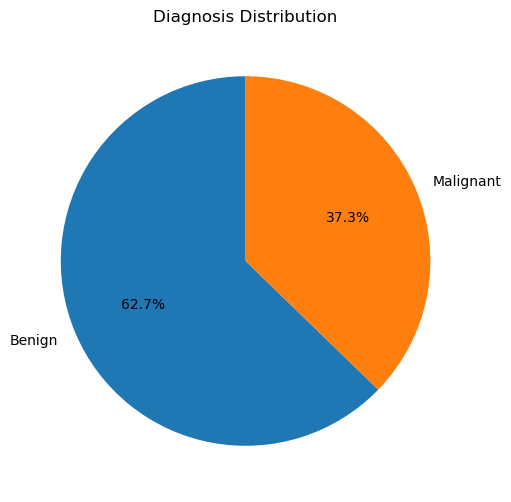

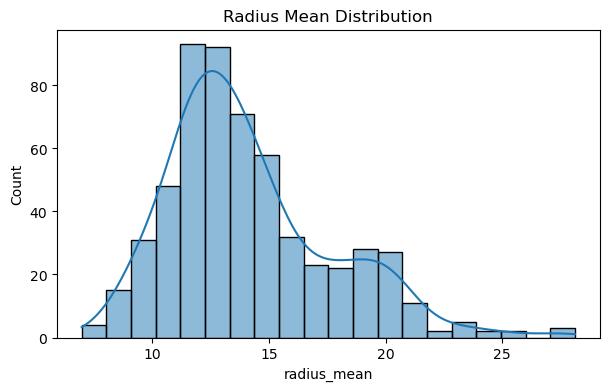

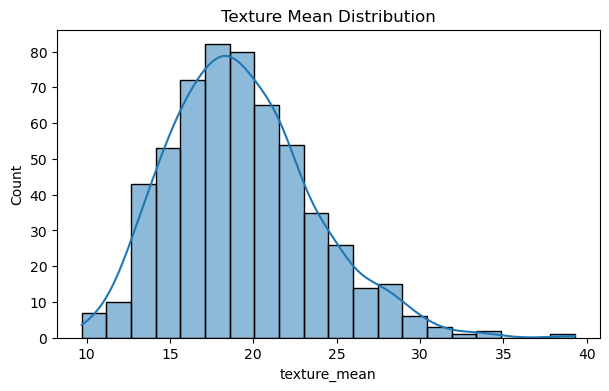

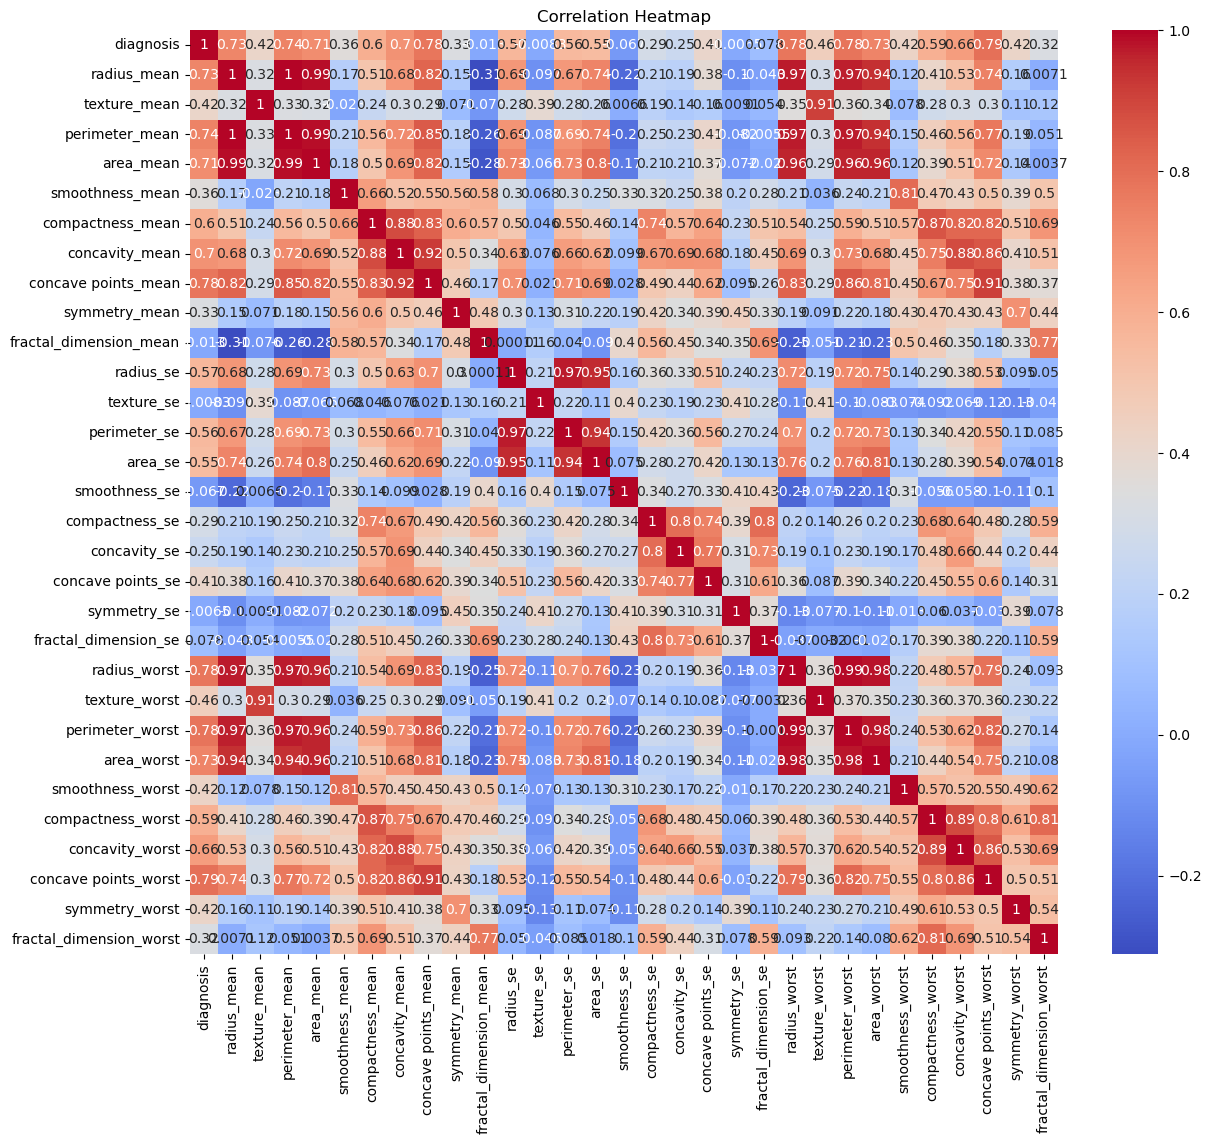

In [30]:
'''
Exploratory Data Analysis
'''

# Diagnosis Distribution
plt.figure(figsize=(5,4))
sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis (0=Benign, 1=Malignant)")
plt.ylabel("Count")
plt.show()

# Pie Chart
plt.figure(figsize=(6,6))
df["diagnosis"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Benign","Malignant"],
    startangle=90
)
plt.title("Diagnosis Distribution")
plt.ylabel("")
plt.show()

# Radius Mean Distribution
plt.figure(figsize=(7,4))
sns.histplot(df["radius_mean"], bins=20, kde=True)
plt.title("Radius Mean Distribution")
plt.show()

# Texture Mean Distribution
plt.figure(figsize=(7,4))
sns.histplot(df["texture_mean"], bins=20, kde=True)
plt.title("Texture Mean Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(14,12))
sns.heatmap(df.corr(), cmap="coolwarm",annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [31]:
'''
Feature Scaling
'''

from sklearn.preprocessing import StandardScaler

# Save column names
columns = X.columns

# Scale Features
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


In [32]:
'''
Train-Test Split
'''

from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (455, 30)
X_test Shape  : (114, 30)
y_train Shape : (455,)
y_test Shape  : (114,)


In [33]:
'''
Logistic Regression Model Training
'''

from sklearn.linear_model import LogisticRegression

# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [34]:
'''
Model Prediction
'''

# Predict on test data
y_pred_lr = lr_model.predict(X_test)

print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred_lr[:10])

First 10 Actual Values:
[0 1 0 1 0 0 1 0 0 0]

First 10 Predicted Values:
[0 1 0 1 1 0 1 0 0 0]


In [35]:
'''
Model Evaluation
'''

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy :", round(accuracy_lr,4))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.9649

Confusion Matrix:

[[71  1]
 [ 3 39]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [36]:
'''
Decision Tree Classifier Model Training
'''

from sklearn.tree import DecisionTreeClassifier

# Create model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully.")

Decision Tree Model Trained Successfully.


In [37]:
'''
Model Prediction
'''

y_pred_dt = dt_model.predict(X_test)

print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred_dt[:10])

First 10 Actual Values:
[0 1 0 1 0 0 1 0 0 0]

First 10 Predicted Values:
[0 1 1 1 0 0 1 0 0 0]


In [38]:
'''
Model Evaluation
'''

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy :", round(accuracy_dt, 4))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.9298

Confusion Matrix:

[[68  4]
 [ 4 38]]

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [39]:
'''
Support Vector Machine (SVM) Model Training
'''

from sklearn.svm import SVC

# Create model
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

# Train model
svm_model.fit(X_train, y_train)

print("SVM Model Trained Successfully.")

SVM Model Trained Successfully.


In [40]:
'''
Model Prediction
'''

y_pred_svm = svm_model.predict(X_test)

print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred_svm[:10])

First 10 Actual Values:
[0 1 0 1 0 0 1 0 0 0]

First 10 Predicted Values:
[0 1 0 0 0 0 1 0 0 0]


In [41]:
'''
Model Evaluation
'''

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy :", round(accuracy_svm, 4))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Accuracy : 0.9737

Confusion Matrix:

[[72  0]
 [ 3 39]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [42]:
'''
KNN Model Training
'''

from sklearn.neighbors import KNeighborsClassifier

accuracy_scores = {}

for k in [3,5,7]:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train,y_train)

    y_pred = knn.predict(X_test)

    accuracy_scores[k] = accuracy_score(y_test,y_pred)

    print(f"k = {k} --> Accuracy = {accuracy_scores[k]:.4f}")

k = 3 --> Accuracy = 0.9386
k = 5 --> Accuracy = 0.9561
k = 7 --> Accuracy = 0.9561


In [43]:
'''
Select Best K Value
'''

best_k = max(accuracy_scores,key=accuracy_scores.get)

print("Best K Value :",best_k)

Best K Value : 5


In [44]:
'''
Final KNN Model Training
'''

knn_model = KNeighborsClassifier(n_neighbors=best_k)

knn_model.fit(X_train,y_train)

print("Final KNN Model Trained Successfully.")

Final KNN Model Trained Successfully.


In [45]:
'''
Model Prediction
'''

y_pred_knn = knn_model.predict(X_test)

print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred_knn[:10])

First 10 Actual Values:
[0 1 0 1 0 0 1 0 0 0]

First 10 Predicted Values:
[0 1 0 0 0 0 1 0 0 0]


In [46]:
'''
Naive Bayes Model Training
'''

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train,y_train)

print("Naive Bayes Model Trained Successfully.")

Naive Bayes Model Trained Successfully.


In [47]:
'''
Model Prediction
'''

y_pred_nb = nb_model.predict(X_test)

print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred_nb[:10])

First 10 Actual Values:
[0 1 0 1 0 0 1 0 0 0]

First 10 Predicted Values:
[0 1 0 0 0 1 1 0 0 0]


In [48]:
'''
Model Evaluation
'''

accuracy_nb = accuracy_score(y_test,y_pred_nb)

print("Accuracy :",round(accuracy_nb,4))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test,y_pred_nb))

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred_nb))

Accuracy : 0.9211

Confusion Matrix:

[[69  3]
 [ 6 36]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



In [49]:
'''
Performance Comparison of Models
'''

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create Comparison Table
comparison = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Decision Tree",
        "Support Vector Machine",
        "K-Nearest Neighbors",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_nb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_nb)
    ]
})

comparison = comparison.round(4)

print("Model Performance Comparison:\n")
print(comparison)

Model Performance Comparison:

                Algorithm  Accuracy  Precision  Recall  F1 Score
0     Logistic Regression    0.9649     0.9750  0.9286    0.9512
1           Decision Tree    0.9298     0.9048  0.9048    0.9048
2  Support Vector Machine    0.9737     1.0000  0.9286    0.9630
3     K-Nearest Neighbors    0.9561     0.9744  0.9048    0.9383
4             Naive Bayes    0.9211     0.9231  0.8571    0.8889


In [50]:
'''
Best Performing Algorithm
'''

best_algorithm = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Algorithm"
]

print("Best Performing Algorithm:", best_algorithm)

print("\nConclusion:")
print(f"{best_algorithm} achieved the highest accuracy among all the classification models and is considered the best-performing model for the Employee Attrition dataset.")

Best Performing Algorithm: Support Vector Machine

Conclusion:
Support Vector Machine achieved the highest accuracy among all the classification models and is considered the best-performing model for the Employee Attrition dataset.


In [51]:
'''
Best Classification Model
'''

best_classification_model = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Algorithm"
]

print("Best Classification Model:", best_classification_model)

Best Classification Model: Support Vector Machine


In [52]:
'''
Save Best Classification Model
'''

import joblib

if best_classification_model == "Logistic Regression":
    best_model = lr_model

elif best_classification_model == "Decision Tree":
    best_model = dt_model

elif best_classification_model == "Support Vector Machine":
    best_model = svm_model

elif "KNN" in best_classification_model:
    best_model = knn_model

else:
    best_model = nb_model

joblib.dump(best_model, "best_classification_model.pkl")
joblib.dump(scaler, "classification_scaler.pkl")
joblib.dump(columns, "classification_columns.pkl")

print("Best Classification Model Saved Successfully.")

Best Classification Model Saved Successfully.


In [53]:
import joblib
import os

# Save All Classification Models
joblib.dump(lr_model, "logistic_model.pkl")
joblib.dump(dt_model, "decision_tree_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(knn_model, "knn_model.pkl")
joblib.dump(nb_model, "naive_bayes_model.pkl")

# Save Best Classification Model
joblib.dump(best_model, "best_classification_model.pkl")

# Save Scaler
joblib.dump(scaler, "employee_scaler.pkl")

# Save Feature Columns
joblib.dump(columns.tolist(), "employee_columns.pkl")

print("Classification models saved successfully!")

print("\nCurrent Directory:")
print(os.getcwd())

print("\nSaved Files:")
for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

Classification models saved successfully!

Current Directory:
C:\Users\rathi_pu888d0\Desktop\ITR\Jupyter Lab

Saved Files:
best_classification_model.pkl
best_regression_model.pkl
classification_columns.pkl
classification_scaler.pkl
decision_tree_model.pkl
decision_tree_regressor.pkl
employee_columns.pkl
employee_scaler.pkl
insurance_columns.pkl
insurance_scaler.pkl
knn_model.pkl
knn_regressor.pkl
linear_regression.pkl
logistic_model.pkl
naive_bayes_model.pkl
regression_columns.pkl
regression_scaler.pkl
svm_model.pkl
svr_model.pkl
